# Flausch detection -- Data Generation

## Dataset

### Load Dataset and prepare

In [3]:
# Load original data
import pandas as pd
import os
import sys
import numpy as np
path = "Input/Data/train/"
#path = ""
file = "comments.csv"
data = pd.read_csv(path + file, encoding='utf-8')
task1 = pd.read_csv(path + "task1.csv", encoding='utf-8')
task2 = pd.read_csv(path + "task2.csv", encoding='utf-8')

In [4]:
# If data with translations is avaiable use this instead

# comments and task1 are original datasets. They are merged to create data.
# if translations are avaiable "data_translated.csv" then use that instead.
# For translating data see below (takes a lot of time)
# currently the data has been tranlated with Helsinki-NLP/opus-mt-en-de

if os.path.exists(path + "translated_data.csv"):
    data = pd.read_csv(path + "translated_data.csv", encoding='utf-8')
else:
    # Merge comments and task1 datasets
    data = pd.merge(data, task1, on=["comment_id","document"], how = "outer")

data2 = pd.merge(task2,data, on=["comment_id","document"], how = "left")

print(data.shape, data2.shape, task1.shape, task2.shape)
data.columns, data2.columns

(37057, 5) (15799, 8) (37057, 3) (15799, 5)


(Index(['document', 'comment_id', 'comment', 'flausch', 'translated'], dtype='object'),
 Index(['document', 'comment_id', 'type', 'start', 'end', 'comment', 'flausch',
        'translated'],
       dtype='object'))

In [12]:
# add span-column to data2. span contains the text span that is annotated with flausch type
data2["span"] = data2.apply(lambda row: row["comment"][row["start"]:(row["end"]+1)], axis=1)

In [13]:
data2.head(3)


,document,comment_id,type,start,end,comment,flausch,translated,span
0,NDY-003,1,compliment,0,11,Respekt : o zu mir passt das heut vollkommen :...,yes,Respect : o to me this fits perfectly today :(...,Respekt : o
1,NDY-003,1,compliment,48,71,Respekt : o zu mir passt das heut vollkommen :...,yes,Respect : o to me this fits perfectly today :(...,Aber Respekt an euch ;)
2,NDY-003,2,positive feedback,0,12,haha geil :D aber ich hab mich am anfang etwas...,yes,haha horny :D but I got a little scared at the...,haha geil :D


In [14]:
# function to get all spans for a comment.
# Returns list of spans, list of start-end-pairs and list of flausch types for a given document and comment id.
def get_all_spans(doc,id,comment,task2):
    doc_bool = np.array(task2["document"] == doc)
    id_bool = np.array(task2["comment_id"] == id)
    bool = doc_bool & id_bool
    sub = task2[bool].reset_index()
    spans = []
    span_pairs = []
    types = []
    for i in range(len(sub)):
        s = sub["start"][i]
        e = sub["end"][i]
        spans.append(comment[s:e])
        span_pairs.append((s,e))
        types.append(sub["type"][i])
    return spans, span_pairs, types



In [8]:
# adds columns spans, span-pairs and types to data
# values are lists that are empty if flausch == no
data["spans"] = data.apply(lambda x: get_all_spans(x["document"], x["comment_id"], x["comment"],task2),axis=1)
data["span_pairs"] = data["spans"].apply(lambda x: x[1])
data["types"] = data["spans"].apply(lambda x: x[2])
data["spans"] = data["spans"].apply(lambda x: x[0])

In [15]:
data[data["flausch"]=="yes"].head(3)

,document,comment_id,comment,flausch,translated
0,NDY-003,1,Respekt : o zu mir passt das heut vollkommen :...,yes,Respect : o to me this fits perfectly today :(...
1,NDY-003,2,haha geil :D aber ich hab mich am anfang etwas...,yes,haha horny :D but I got a little scared at the...
2,NDY-003,3,würd gern mit euch tanzen * - * haha,yes,Would like to dance with you * - * haha


### Data analysis

In [16]:
print("Flausch yes/no distribution:")
task1["flausch"].value_counts()

Flausch yes/no distribution:


no     26284
yes    10773
Name: flausch, dtype: int64

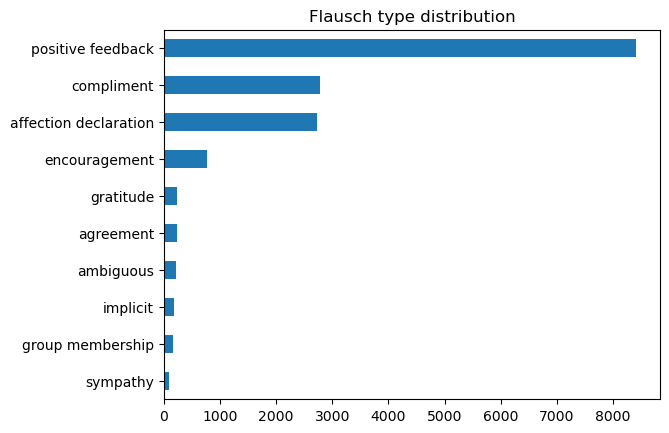

In [17]:

import matplotlib.pyplot as plt
task2["type"].value_counts(ascending=True).plot.barh()
plt.title("Flausch type distribution")
plt.show()

In [18]:
print("length of comments:")
data["comment"].apply(lambda x: len(x)).describe()

length of comments:


count    37057.000000
mean        58.345090
std        103.581884
min          1.000000
25%         18.000000
50%         35.000000
75%         68.000000
max       9529.000000
Name: comment, dtype: float64

In [19]:
print("Number of words in comments:")
data["comment"].apply(lambda x: len(x.split())).describe()

Number of words in comments:


count    37057.000000
mean        11.594571
std         20.462793
min          1.000000
25%          4.000000
50%          7.000000
75%         14.000000
max       1880.000000
Name: comment, dtype: float64

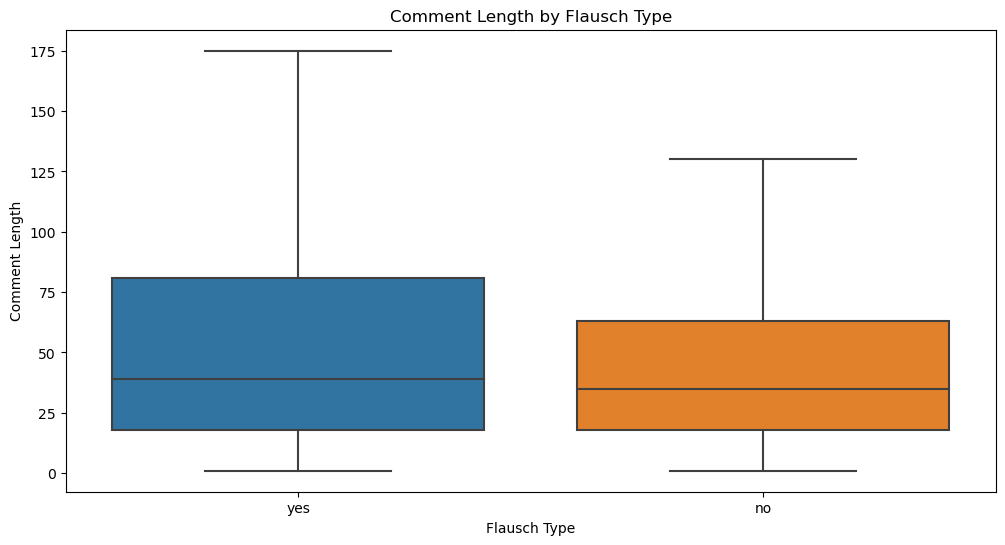

In [20]:
#  plot per flausch yes/no boxplots of comment length
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x="flausch", y=data["comment"].apply(lambda x: len(x)), data=data,showfliers=False,)
plt.title("Comment Length by Flausch Type")
plt.xlabel("Flausch Type")
plt.ylabel("Comment Length")
plt.show()

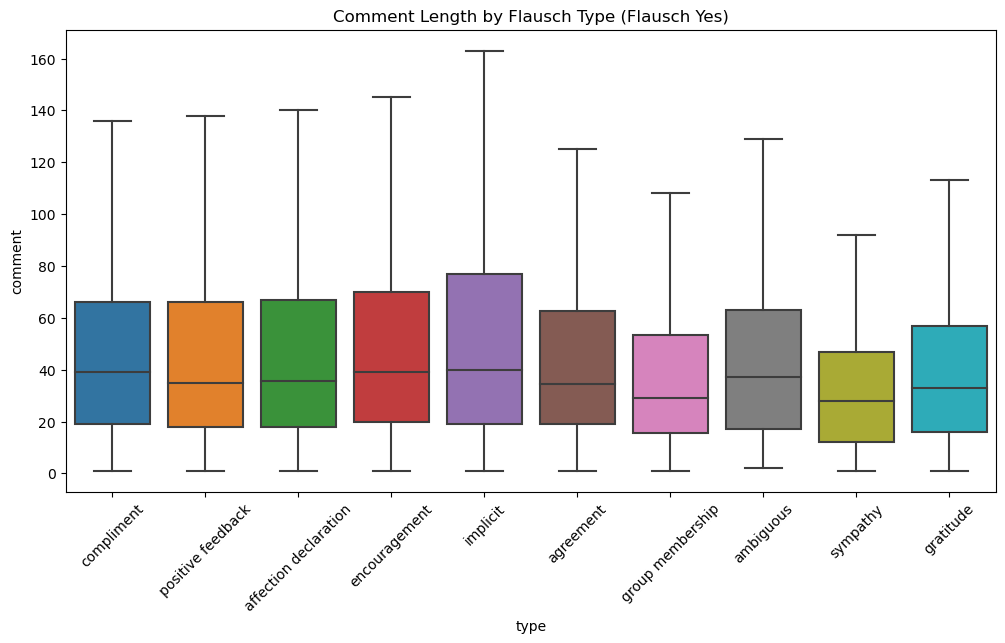

In [21]:
# plot per flausch type the boxplot of the comment length
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x="type", y=data["comment"].apply(lambda x: len(x)), data=data2[data2["flausch"]=="yes"],showfliers=False)
plt.title("Comment Length by Flausch Type (Flausch Yes)")
# x-axis label rotation
plt.xticks(rotation=45)
plt.show()

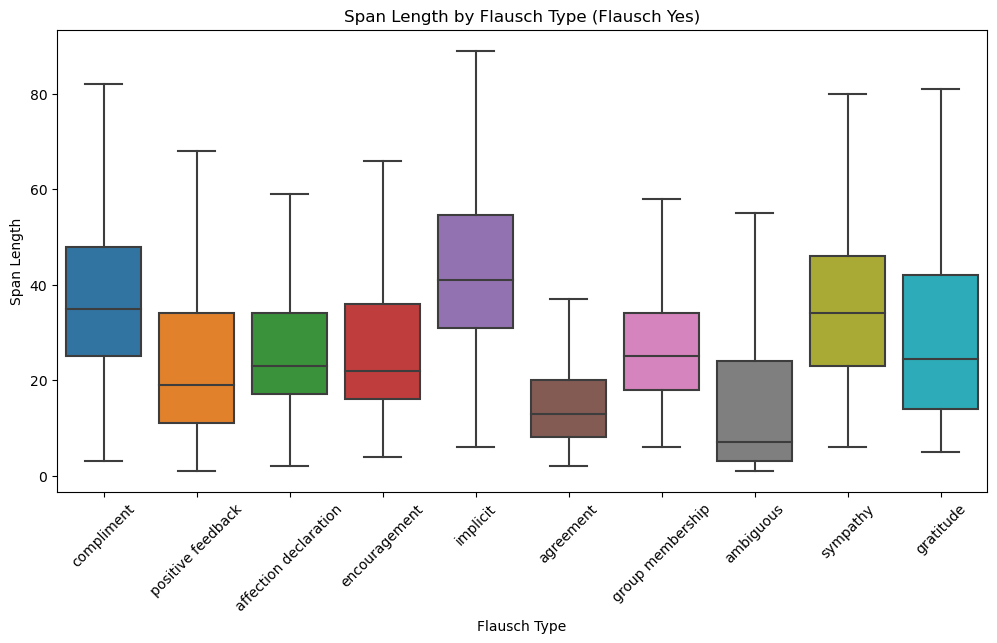

In [22]:
# plot per flausch type boxplot for span length
plt.figure(figsize=(12, 6))
sns.boxplot(x="type", y=data2["span"].apply(lambda x: len(x)), data=data2[data2["flausch"]=="yes"],showfliers=False)
plt.title("Span Length by Flausch Type (Flausch Yes)")
plt.xlabel("Flausch Type")
plt.ylabel("Span Length")
# x-axis label rotation
plt.xticks(rotation=45)

plt.show()

### Split in test and train data

In [23]:
# add id column
data["id"] =    data["document"] + "_" + data["comment_id"].astype(str)
data2["id"] = data2["document"] + "_" + data2["comment_id"].astype(str)

In [24]:
# split data into train and test sets (test set is not touched for training or hyperparameter tuning)
from sklearn.model_selection import train_test_split

train_task1, test_task1 = train_test_split(data, test_size=0.1, random_state=42)


In [25]:
train_task2 = data2[data2["id"].isin(train_task1["id"])]
test_task2 = data2[data2["id"].isin(test_task1["id"])]

In [ ]:
# for safety reasons commented out to not overwrite existing files
#train_task1.to_json(path + "train_task1.json")
#test_task1.to_json(path + "test_task1.json")#train_task2.to_json(path + "train_task2.json")
#test_task2.to_json(path + "test_task2.json")

## Spacy Dependency Trees (ToDo)

 Labels: dep spacy https://universaldependencies.org/u/dep/


a->c
b->c
c->d
d->e
f->e
g->d
h->k
i->k
j->n
k->l
l->e
m->l
n->e

T = (e,[(d,[
            (c,[(a,[]),(b,[])]),
            (f,[]),
            (g,[])]),
        (l,[
            (k,[(h,[]),(i,[])])]),
            (l,[(m,[])]),
            (n,[(j,[])])])





In [24]:
import spacy
nlp = spacy.load("en_core_web_sm")


data_small = data.sample(1000, random_state=42)
data_small["spacy_nlp"] = data_small["translated"].apply(lambda x: nlp(x))





In [27]:
spac = data_small.iloc[1]["spacy_nlp"]
for token in spac:
    print(token.text, token.dep, token.tag)


Well 421 3252815442139690129
the 415 15267657372422890137
translation 429 15308085513773655218
is 8206900633647566924 13927759927860985106
not 425 164681854541413346
so 400 164681854541413346
great 398 10554686591937588953
and 407 17571114184892886314
your 440 4062917326063685704
voice 429 15308085513773655218
is 410 13927759927860985106
terrible 398 10554686591937588953


## Generate Translations

### Model: "Helsinki-NLP/opus-mt-de-en"

Runs on local machine. (690 minutes)

In [ ]:
#!pip install --upgrade translators


In [ ]:
import pandas as pd
from transformers import pipeline
import time
import os

# --- 2. Konfiguration ---
MODEL_NAME = "Helsinki-NLP/opus-mt-de-en"
BATCH_SIZE = 64  # Optimale Batch-Größe kann je nach GPU/CPU variieren
SAVE_INTERVAL = 500 # Speichert alle 500 übersetzten Kommentare
OUTPUT_FILE = "translated_data_checkpoint.csv" # Dateiname für Zwischenspeicherung und Endprodukt
BACKUP_DIR = "translation_backups" # Verzeichnis für Backups vor dem Überschreiben

# Sicherstellen, dass das Backup-Verzeichnis existiert
os.makedirs(BACKUP_DIR, exist_ok=True)

# --- 3. Übersetzer laden ---
print(f"Lade Übersetzungsmodell: {MODEL_NAME}...")
# Das Pipeline erkennt automatisch den passenden Tokenizer und das Modell.
# Falls du eine GPU hast, kannst du device=0 hinzufügen:
# translator = pipeline("translation", model=MODEL_NAME, device=0)
translator = pipeline("translation", model=MODEL_NAME)
print("Modell erfolgreich geladen.")

# --- 4. Übersetzungsfunktion ---
def translate_comments_batched(dataframe, comment_column="comment", batch_size=BATCH_SIZE, save_interval=SAVE_INTERVAL, output_file=OUTPUT_FILE, backup_dir=BACKUP_DIR):
    total_comments = len(dataframe)

    # Prüfen, ob eine Teildatei existiert und Laden des Fortschritts
    if os.path.exists(output_file):
        print(f"Bestehende Übersetzungsdatei gefunden: {output_file}. Lade Fortschritt...")
        try:
            temp_df = pd.read_csv(output_file)
            if "translated" in temp_df.columns:
                # Sicherstellen, dass die Längen übereinstimmen
                if len(temp_df) == total_comments:
                    # Wenn die Datei die gleiche Größe hat und eine übersetzte Spalte,
                    # gehen wir davon aus, dass alles übersetzt ist.
                    print("Alle Kommentare scheinen bereits übersetzt zu sein. Beende Vorgang.")
                    return temp_df

                # Finde den letzten übersetzten Index
                last_translated_idx = temp_df["translated"].last_valid_index()
                if last_translated_idx is not None:
                    # Wenn der letzte Wert None ist, aber es davor übersetzte gab,
                    # müssen wir den Index des letzten *echten* übersetzten Eintrags finden.
                    start_index = last_translated_idx + 1
                    # Wenn die letzten Einträge leer sind, suchen wir nach dem letzten Nicht-Null-Wert
                    while start_index > 0 and pd.isna(temp_df.loc[start_index - 1, "translated"]):
                        start_index -= 1

                    if start_index < total_comments:
                        dataframe["translated"] = temp_df["translated"] # Vorhandene Übersetzungen übernehmen
                        print(f"Fortsetzung der Übersetzung ab Kommentar {start_index} von {total_comments}.")
                    else:
                        print("Alle Kommentare scheinen bereits übersetzt zu sein (nachprüfung). Beende Vorgang.")
                        return temp_df
                else: # Keine übersetzten Kommentare in der Datei gefunden, starte von vorn
                    dataframe["translated"] = pd.Series([None] * total_comments) # Initialisiere mit None
                    start_index = 0
                    print("Starte Übersetzung von Anfang an (keine gültigen Übersetzungen in der Datei gefunden).")
            else: # Datei existiert, hat aber keine "translated"-Spalte
                dataframe["translated"] = pd.Series([None] * total_comments)
                start_index = 0
                print("Starte Übersetzung von Anfang an (keine 'translated' Spalte gefunden).")
        except Exception as e:
            print(f"Fehler beim Laden der Checkpoint-Datei: {e}. Starte von vorne.")
            dataframe["translated"] = pd.Series([None] * total_comments) # Initialisiere mit None
            start_index = 0
    else:
        dataframe["translated"] = pd.Series([None] * total_comments) # Initialisiere mit None
        start_index = 0
        print("Starte Übersetzung von Anfang an (keine Checkpoint-Datei gefunden).")

    start_time = time.time()

    for i in range(start_index, total_comments, batch_size):
        batch_end_index = min(i + batch_size, total_comments)

        # Sicherstellen, dass der Batch nur die noch nicht übersetzten Texte enthält
        batch_to_translate_df = dataframe.iloc[i:batch_end_index]

        # Filtere leere Strings oder NaN-Werte, um sie nicht an das Modell zu senden
        # und speichere die ursprünglichen Indizes, um die Ergebnisse richtig zuzuordnen
        texts_to_process_indices = batch_to_translate_df[comment_column].apply(lambda x: pd.notna(x) and str(x).strip() != "").index.tolist()
        texts_to_process = [str(dataframe.loc[idx, comment_column]) for idx in texts_to_process_indices]

        translated_batch = []
        if texts_to_process:
            try:
                # Das Pipeline kann eine Liste von Strings verarbeiten
                results = translator(texts_to_process)
                translated_batch = [item['translation_text'] for item in results]
            except Exception as e:
                print(f"Fehler beim Übersetzen des Batches {i}-{batch_end_index-1}: {e}")
                # Im Fehlerfall füllen wir den Batch mit None oder dem Originaltext
                translated_batch = [None] * len(texts_to_process)

        # Ergebnisse den ursprünglichen Indizes zuordnen
        translated_results_map = {}
        for j, original_idx in enumerate(texts_to_process_indices):
            if j < len(translated_batch):
                translated_results_map[original_idx] = translated_batch[j]
            else:
                translated_results_map[original_idx] = None # Fehler oder fehlende Übersetzung

        # Original-DataFrame aktualisieren
        for idx in range(i, batch_end_index):
            if idx in translated_results_map:
                dataframe.loc[idx, "translated"] = translated_results_map[idx]
            elif pd.isna(dataframe.loc[idx, comment_column]) or str(dataframe.loc[idx, comment_column]).strip() == "":
                dataframe.loc[idx, "translated"] = "" # Leere Eingaben bleiben leer
            else:
                dataframe.loc[idx, "translated"] = None # Oder den Originaltext lassen, wenn ein unerwarteter Fehler auftritt

        current_progress = batch_end_index
        if current_progress % save_interval == 0 or current_progress == total_comments:
            elapsed_time = time.time() - start_time
            print(f"Fortschritt: {current_progress}/{total_comments} Posts übersetzt. "
                  f"Verstrichene Zeit: {elapsed_time:.2f} Sekunden.")

            # Sicherungskopie erstellen, bevor die Hauptdatei überschrieben wird
            backup_path = os.path.join(backup_dir, f"{OUTPUT_FILE.replace('.csv', '')}_backup_{current_progress}.csv")
            dataframe.to_csv(backup_path, index=False)
            print(f"Zwischenstand als Backup gespeichert: {backup_path}")

            # Hauptdatei aktualisieren
            dataframe.to_csv(output_file, index=False)
            print(f"Zwischenstand in {output_file} gespeichert.")

    print("\nÜbersetzung abgeschlossen!")
    return dataframe

# --- 5. Ausführung ---
if __name__ == "__main__":
    # Stelle sicher, dass dein 'data' DataFrame hier geladen ist,
    # wenn es nicht das Beispiel-DataFrame ist.
    # z.B.: data = pd.read_csv("your_data.csv")

    # Füge eine leere Spalte "translated" hinzu, falls sie noch nicht existiert
    if "translated" not in data.columns:
        data["translated"] = pd.Series([None] * len(data))

    final_data = translate_comments_batched(data.copy()) # Erstelle eine Kopie, um das Original nicht direkt zu ändern

    print("\nÜbersetzter DataFrame:")
    print(final_data.head())

    # Optional: Speichere das finale Ergebnis erneut
    final_data.to_csv("final_translated_data.csv", index=False)
    print(f"Endgültige übersetzte Daten in 'final_translated_data.csv' gespeichert.")

Lade Übersetzungsmodell: Helsinki-NLP/opus-mt-de-en...


Device set to use cpu


Modell erfolgreich geladen.
Starte Übersetzung von Anfang an (keine Checkpoint-Datei gefunden).
Fortschritt: 8000/37057 Posts übersetzt. Verstrichene Zeit: 8493.89 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_8000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.
Fortschritt: 16000/37057 Posts übersetzt. Verstrichene Zeit: 18746.84 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_16000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.


Token indices sequence length is longer than the specified maximum sequence length for this model (1516 > 512). Running this sequence through the model will result in indexing errors
Your input_length: 1516 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


Fehler beim Übersetzen des Batches 16576-16639: index out of range in self


...

Fehler beim Übersetzen des Batches 19712-19775: index out of range in self
Fortschritt: 24000/37057 Posts übersetzt. Verstrichene Zeit: 28602.66 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_24000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.


Your input_length: 538 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


Fehler beim Übersetzen des Batches 27520-27583: index out of range in self
Fortschritt: 32000/37057 Posts übersetzt. Verstrichene Zeit: 36039.61 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_32000.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.


Your input_length: 2671 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


Fehler beim Übersetzen des Batches 32128-32191: index out of range in self
Fortschritt: 37057/37057 Posts übersetzt. Verstrichene Zeit: 41147.23 Sekunden.
Zwischenstand als Backup gespeichert: translation_backups\translated_data_checkpoint_backup_37057.csv
Zwischenstand in translated_data_checkpoint.csv gespeichert.

Übersetzung abgeschlossen!

Übersetzter DataFrame:
  document  comment_id                                            comment  \
0  NDY-003           1  Respekt : o zu mir passt das heut vollkommen :...   
1  NDY-003           2  haha geil :D aber ich hab mich am anfang etwas...   
2  NDY-003           3               würd gern mit euch tanzen * - * haha   
3  NDY-003           4  Einfach nur wieder geil ... ich mag eure texte...   
4  NDY-003           5                                 das ist so geil :)   

  flausch                                         translated  
0     yes  Respect : o to me this fits perfectly today :(...  
1     yes  haha horny :D but I got a litt

In [ ]:
missing_translation = final_data[final_data["translated"].isna()].copy()
for i in range(len(missing_translation)):
    text = missing_translation["comment"].iloc[i]
    translated = translator(text, src_lang="de", tgt_lang="en", max_length= 512, truncation= True)[0]["translation_text"]
    missing_translation["translated"].iloc[i] = translated

C:\Users\Wiebke Petersen\AppData\Local\Temp\ipykernel_38764\1026092389.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_translation["translated"].iloc[i] = translated
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 512 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_

In [ ]:
for i in missing_translation.index:
    final_data.loc[i,"translated"] = missing_translation.loc[i,"translated"]

In [ ]:
final_data.to_csv(path + "translated_data.csv", index=False)

### Model  "facebook/mbart-large-50-many-to-many-mmt"

In [ ]:
# mit MBART dauert lange ab 10.000 Fehler
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import time
import os
import torch # Importiere torch, um GPU-Verfügbarkeit zu prüfen



# --- 2. Konfiguration ---
MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"
BATCH_SIZE = 8  # WICHTIG: Starte mit 16 oder weniger für mBART auf Colab-GPUs. Passe an!
SAVE_INTERVAL = 500 # Speichert alle 1000 übersetzten Kommentare
OUTPUT_FILE = path + "translated_data_mbart.csv" # Dateiname für Zwischenspeicherung und Endprodukt
BACKUP_DIR = path + "translation_backups_final_mbart" # Verzeichnis für Backups vor dem Überschreiben

# Sicherstellen, dass das Backup-Verzeichnis existiert
os.makedirs(BACKUP_DIR, exist_ok=True)

# --- 3. Modell und Tokenizer laden (mit GPU-Erkennung) ---
print(f"Lade Übersetzungsmodell: {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Prüfen, ob eine GPU verfügbar ist und Modell dorthin verschieben
if torch.cuda.is_available():
    device = "cuda"
    model.to(device)
    print("GPU gefunden! Modell auf GPU geladen.")
else:
    device = "cpu"
    print("Keine GPU gefunden. Modell auf CPU geladen (wird deutlich langsamer sein).")

print("Modell erfolgreich geladen.")

# --- 4. Übersetzungsfunktion ---
def translate_comments_mbart_batched(dataframe, comment_column="comment", batch_size=BATCH_SIZE, save_interval=SAVE_INTERVAL, output_file=OUTPUT_FILE, backup_dir=BACKUP_DIR):
    total_comments = len(dataframe)

    # Spracheinstellungen für mBART
    # de_DE ist das Sprach-Token für Deutsch
    # en_XX ist das Sprach-Token für Englisch (generisches Englisch)
    source_lang_token = "de_DE"
    target_lang_token = "en_XX"

    # Initialisiere die "translated"-Spalte mit None oder lade den Fortschritt
    if "translated" not in dataframe.columns:
        dataframe["translated"] = pd.Series([None] * total_comments)

    start_index = 0
    if os.path.exists(output_file):
        print(f"Bestehende Übersetzungsdatei gefunden: {output_file}. Lade Fortschritt...")
        try:
            temp_df = pd.read_csv(output_file)
            if "translated" in temp_df.columns and len(temp_df) == total_comments:
                # Finde den ersten Index, der noch nicht übersetzt wurde (oder NaN/None ist)
                for idx in range(total_comments - 1, -1, -1):
                    if pd.notna(temp_df.loc[idx, "translated"]) and str(temp_df.loc[idx, "translated"]).strip() != "":
                        start_index = idx + 1
                        break

                if start_index < total_comments:
                    dataframe["translated"] = temp_df["translated"] # Vorhandene Übersetzungen übernehmen
                    print(f"Fortsetzung der Übersetzung ab Kommentar {start_index} von {total_comments}.")
                else:
                    print("Alle Kommentare scheinen bereits übersetzt zu sein. Beende Vorgang.")
                    return temp_df
            else: # Datei existiert, aber nicht im erwarteten Format oder Länge
                print("Checkpoint-Datei ist nicht im erwarteten Format oder unvollständig. Starte von vorne.")
                dataframe["translated"] = pd.Series([None] * total_comments)
                start_index = 0
        except Exception as e:
            print(f"Fehler beim Laden der Checkpoint-Datei: {e}. Starte von vorne.")
            dataframe["translated"] = pd.Series([None] * total_comments)
            start_index = 0
    else:
        print("Starte Übersetzung von Anfang an (keine Checkpoint-Datei gefunden).")

    start_time = time.time()

    for i in range(start_index, total_comments, batch_size):
        batch_end_index = min(i + batch_size, total_comments)

        # Erfasse die Original-Indizes und die Texte für den aktuellen Batch
        batch_indices = dataframe.iloc[i:batch_end_index].index.tolist()
        batch_texts = [str(dataframe.loc[idx, comment_column]) for idx in batch_indices]

        # Filtere leere Strings oder NaN-Werte für die Verarbeitung
        texts_to_process = []
        original_idx_map = [] # Speichert den ursprünglichen DataFrame-Index für jeden Text, der verarbeitet wird
        for idx, text in zip(batch_indices, batch_texts):
            if pd.notna(text) and text.strip() != "":
                texts_to_process.append(text)
                original_idx_map.append(idx)
            else:
                dataframe.loc[idx, "translated"] = "" # Leere Eingaben bleiben leer

        translated_batch = []
        if texts_to_process:
            try:
                # Wichtig: src_lang muss vor der Tokenisierung gesetzt werden
                tokenizer.src_lang = source_lang_token

                # Tokenisieren der Eingaben
                # truncation=True ist wichtig für lange Texte, um Speicherprobleme zu vermeiden
                encoded_inputs = tokenizer(texts_to_process, return_tensors="pt", padding=True, truncation=True)

                # Eingaben auf die gleiche Hardware wie das Modell verschieben
                if device == "cuda":
                    encoded_inputs = {k: v.to(device) for k, v in encoded_inputs.items()}

                # Generieren der Übersetzungen
                generated_tokens = model.generate(
                    **encoded_inputs,
                    forced_bos_token_id=tokenizer.lang_code_to_id[target_lang_token], # Zielsprache
                    max_length=512 # Limitiere die Länge des generierten Textes, um OOM zu vermeiden
                )

                # Decodieren der übersetzten Tokens
                translated_batch = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"CUDA Out of Memory Fehler für Batch {i}-{batch_end_index-1}. Versuche kleinere BATCH_SIZE.")
                else:
                    print(f"Laufzeitfehler für Batch {i}-{batch_end_index-1}: {e}")
                translated_batch = [None] * len(texts_to_process) # Bei Fehler, None für diesen Batch
                # Optional: Hier könnte man versuchen, den Batch zu halbieren und erneut zu verarbeiten
            except Exception as e:
                print(f"Allgemeiner Fehler beim Übersetzen des Batches {i}-{batch_end_index-1}: {e}")
                translated_batch = [None] * len(texts_to_process)

        # Ergebnisse dem DataFrame zuordnen
        for j, original_df_idx in enumerate(original_idx_map):
            if j < len(translated_batch):
                dataframe.loc[original_df_idx, "translated"] = translated_batch[j]
            else:
                dataframe.loc[original_df_idx, "translated"] = None # Fallback bei Fehlern oder unerwarteten Längen

        current_progress = batch_end_index
        if current_progress % save_interval == 0 or current_progress == total_comments:
            elapsed_time = time.time() - start_time
            print(f"Fortschritt: {current_progress}/{total_comments} Posts übersetzt. "
                  f"Verstrichene Zeit: {elapsed_time:.2f} Sekunden.")

            # Sicherungskopie erstellen, bevor die Hauptdatei überschrieben wird
            backup_path = os.path.join(backup_dir, f"{OUTPUT_FILE.replace('.csv', '')}_backup_{current_progress}.csv")
            dataframe.to_csv(backup_path, index=False)
            print(f"Zwischenstand als Backup gespeichert: {backup_path}")

            # Hauptdatei aktualisieren
            dataframe.to_csv(output_file, index=False)
            print(f"Zwischenstand in {output_file} gespeichert.")

    print("\nÜbersetzung abgeschlossen!")
    return dataframe

# --- 5. Ausführung ---
if __name__ == "__main__":
    # Stellen Sie sicher, dass die Spalte "translated" vorhanden ist, falls nicht, wird sie initialisiert
    if "translated" not in data.columns:
        data["translated"] = pd.Series([None] * len(data))

    # Wichtig: Erstellen Sie eine Kopie des DataFrames, um Warnungen zu vermeiden
    final_data = translate_comments_mbart_batched(data.copy())

    print("\nÜbersetzter DataFrame (erste 5 Zeilen):")
    print(final_data.head())

    # Optional: Speichere das finale Ergebnis erneut
    final_data.to_csv("final_translated_data_mbart.csv", index=False)
    print(f"Endgültige übersetzte Daten in 'final_translated_data_mbart.csv' gespeichert.")

    # Wenn du das Ergebnis in Google Drive speichern möchtest:
    # from google.colab import drive
    # drive.mount('/content/drive')
    # final_data.to_csv('/content/drive/MyDrive/final_translated_data_mbart.csv', index=False)
    # print(f"Endgültige übersetzte Daten in Google Drive gespeichert.")

### Translators library (not successfull, too many items)

In [ ]:
import time
import translators as ts


def translate(text, target_language='en'):
    y=""
    time.sleep(0.1)
    try:
        translated_text = ts.translate_text(text, from_language="de", to_language="en",
                                            ##translator="deepl")
                                            translator = "alibaba")
                                            #translator="bing")
                                            #translator="google")
        return translated_text
    except:
        return y  # Return empty string if translation fails

In [ ]:
text1 = "Omg 😍 omg 😍 omg 😍 das video ist einfach so shönn geworden aww deine augen sind so sc Hönn 😍 😍 ich liebe diich und deine videos yoh sehr ❤ love you LuNa 😍 😘"
text2 = "ohaaa :D dieses Lied ist HAMMER ♥ nach einem mal anhören , konnte ich ( wir ) schon den Refrain ;) das Lied ist der Hit Leute ;) und endlich ist es da ♥"

print(translate(text1))
print(translate(text2))

Omg😍Omg😍Omg😍The video has just become so shönn aww your eyes are so sc😍😍I love diich and your videos yoh very much❤Love you LuNa😍😘
Ohaaa: D this song is HAMMER♥After a time, I (we) could already listen to the chorus;) the song is the hit people;) and finally it&#39;s there♥


In [ ]:
ts.translators_pool

['alibaba',
 'apertium',
 'argos',
 'baidu',
 'bing',
 'caiyun',
 'cloudTranslation',
 'deepl',
 'elia',
 'google',
 'hujiang',
 'iciba',
 'iflytek',
 'iflyrec',
 'itranslate',
 'judic',
 'languageWire',
 'lingvanex',
 'niutrans',
 'mglip',
 'mirai',
 'modernMt',
 'myMemory',
 'papago',
 'qqFanyi',
 'qqTranSmart',
 'reverso',
 'sogou',
 'sysTran',
 'tilde',
 'translateCom',
 'translateMe',
 'utibet',
 'volcEngine',
 'yandex',
 'yeekit',
 'youdao']

#batches : minutes
0 :

In [ ]:
# zu große Datenmenge funktioniert nicht
import pickle
list = []
start = 0 #25
k = 100
end = 380
for i in range(start,end):
    data_small = data[k*i:k*(i+1)].copy()
#    data_small["comment_google"] = data_small["comment"].apply(lambda x: translate(x))
    list.append(data_small)
    if i % 5 == 0:
        print(i)
#        with open("Input/Data/train/list_comments_translated.pkl", "wb") as f:
#            pickle.dump(list, f)


0


In [ ]:
# read pickle file
with open("Input/Data/train/list_comments_translated.pkl", "rb") as f:
    list = pickle.load(f)

len(list), list[0]

NameError: name 'pickle' is not defined

In [ ]:
for t in data["comment"][2895:2900]:
    print(ts.translate_text(t, from_language="de", to_language="en", translator="google"))

I love you Heiko
Heiko I love you !!!!!!!!!!!!! 😍 😉 😍 😍 😍 😍 😍
Again no xD
Do they make Google translator? X'D and you are (: 12 or already 13? :)
If you think you are good then go to the super talent.


In [ ]:
help(ts.translate_text)


Help on method translate_text in module translators.server:

translate_text(query_text: str, translator: str = 'alibaba', from_language: str = 'auto', to_language: str = 'en', if_use_preacceleration: bool = False, **kwargs: Union[str, int, float, bool, dict]) -> Union[str, dict] method of translators.server.TranslatorsServer instance
    :param query_text: str, must.
    :param translator: str, default 'alibaba'.
    :param from_language: str, default 'auto'.
    :param to_language: str, default 'en'.
    :param if_use_preacceleration: bool, default False.
    :param **kwargs:
            :param is_detail_result: bool, default False.
            :param http_client: str, default 'requests'. Union['requests', 'niquests', 'httpx']
            :param professional_field: str, support alibaba(), baidu(), caiyun(), cloudTranslation(), elia(), sysTran(), youdao(), volcEngine() only.
            :param timeout: Optional[float], default None.
            :param proxies: Optional[dict], default N